# Exercise Objective:

Build an image classifier in Keras that detects fashion items from low res images. The training set contains 60,000 grayscale images, each 28x28 pixels. There are 10 classes, all different clothes items.

In this work, you need to:

__Exercise 1__
1. Train a sequential, fully connected neural net to classify the clothes.
2. Assess the performance.

__Exercise 2__
3. Train a sequential, convolutional neural net to classify the clothes.
4. Compare the performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

Let's start by loading the fashion mnist dataset as we did back in week 9.

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's make sure the input pixel data is float64. We'll also split off some validation data.

In [3]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

In [4]:
X_train.dtype

dtype('float64')

In [5]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Let's see what the data looks like. Rerun to see more examples.

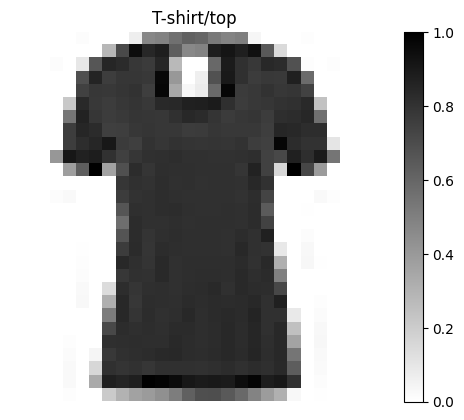

In [6]:
rand_idx = np.random.choice(range(X_train.shape[0]))
plt.imshow(X_train[rand_idx], cmap="binary")
plt.colorbar()
plt.axis('off')
plt.title(class_names[y_train[rand_idx]]);

## Exercise 1
Build the dense model.

In [ ]:
## YOUR CODE HERE ##

In [7]:
img_size = (28, 28)
layer_sizes = (128, 64)
n_classes = 10

In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=img_size),
    Dense(layer_sizes[0], activation='selu',
          kernel_initializer='lecun_normal'),
    Dense(layer_sizes[1], activation='selu',
          kernel_initializer='lecun_normal'),
    Dense(n_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
learning_rate = 0.005
n_epochs = 20

In [22]:
from tensorflow.keras.optimizers import Nadam

optimizer = Nadam(learning_rate=learning_rate)

In [23]:
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint

save_cb = ModelCheckpoint("dense_fashion_model.h5",
                          save_best_only=True)

In [25]:
optimizer = Nadam(learning_rate=learning_rate)

In [18]:
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=n_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[save_cb]
)

Epoch 1/20
1715/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7813 - loss: 0.6220

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8182 - loss: 0.5038 - val_accuracy: 0.8396 - val_loss: 0.4678
Epoch 2/20
1707/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8480 - loss: 0.4192

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8510 - loss: 0.4120 - val_accuracy: 0.8576 - val_loss: 0.4310
Epoch 3/20
1712/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8589 - loss: 0.3900

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8613 - loss: 0.3849 - val_accuracy: 0.8702 - val_loss: 0.3834
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8674 - loss: 0.3658 - val_accuracy: 0.8702 - val_loss: 0.3851
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8738 - loss: 0.3502 - val_accuracy: 0.8650 - val_loss: 0.3941
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8785 - loss: 0.3397 - val_accuracy: 0.8688 - val_loss: 0.4152
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8820 - loss: 0.3270 - val_accuracy: 0.8736 - val_loss: 0.3917
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8844 - loss: 0.3197 - val_accuracy: 0.8676 - val_loss: 0.4519
Epoch 9/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8897 - loss: 0.3120 - val_accuracy: 0.8750 - val_loss: 0.4498
Epoch 10/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8913 - loss: 0.3045 - val_accura

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1);

The training results indicate that the model is learning effectively, as evidenced by the steady increase in training accuracy and the decrease in training loss. The validation accuracy follows a similar trend, remaining relatively close to the training accuracy, which suggests good generalization initially.

However, the validation loss begins to fluctuate and slightly increase after several epochs, indicating the onset of mild overfitting. This suggests that while the model continues to improve on the training data, its performance on unseen data does not improve at the same rate.

Overall, the model demonstrates good performance, but early stopping or regularization techniques could be applied to further improve generalization.

Evaluate the model.

In [27]:
from tensorflow.keras.models import load_model

model = load_model('dense_fashion_model.h5')

In [29]:
import numpy as np

y_probs = model.predict(X_test)
y_hat = np.argmax(y_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


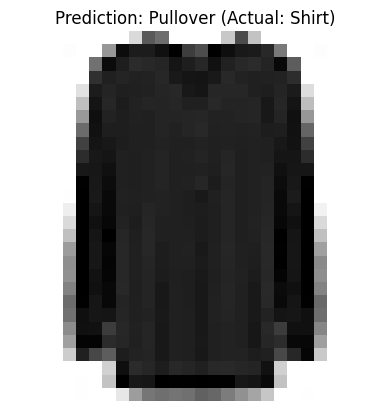

In [30]:
def plot_prediction():
    rand_idx = np.random.choice(range(X_test.shape[0]))
    image = X_test[rand_idx].squeeze()
    prediction = class_names[y_hat[rand_idx]]
    actual = class_names[y_test[rand_idx]]

    plt.imshow(image, cmap="binary")
    plt.axis('off')
    plt.title(f"Prediction: {prediction} (Actual: {actual})")

plot_prediction()

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1000
           1       0.99      0.95      0.97      1000
           2       0.67      0.86      0.75      1000
           3       0.89      0.84      0.86      1000
           4       0.71      0.79      0.75      1000
           5       0.97      0.94      0.95      1000
           6       0.73      0.52      0.61      1000
           7       0.94      0.92      0.93      1000
           8       0.98      0.93      0.95      1000
           9       0.91      0.97      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000



## Exercise 2

__NOTE:__
It is important to add a channel dimension to images going into convolutions, even if that dimension is simply 1 (greyscale). You can unsqueeze the numpy array like so:

In [33]:
X_train.shape

(55000, 28, 28)

In [34]:
X_train = X_train[..., None]
X_valid = X_valid[..., None]
X_test = X_test[..., None]

In [35]:
X_train.shape

(55000, 28, 28, 1)

Build the convolutional model.

In [ ]:
## YOUR CODE HERE ##

In [36]:
img_size = (28, 28, 1)
layer_sizes = (128, 64)
n_filters = (64, 128, 256)
kernel_sizes = (7, 3, 3)
pool_size = 2
drop_prob = 0.5

In [37]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

model = Sequential([
    Conv2D(n_filters[0], kernel_sizes[0],
           activation='relu', padding='same',
           input_shape=img_size),
    MaxPooling2D(pool_size),
    Conv2D(n_filters[1], kernel_sizes[1],
           activation='relu', padding='same'),
     Conv2D(n_filters[1], kernel_sizes[1],
           activation='relu', padding='same'),
    MaxPooling2D(pool_size),
    Conv2D(n_filters[2], kernel_sizes[2],
           activation='relu', padding='same'),
    Conv2D(n_filters[2], kernel_sizes[2],
           activation='relu', padding='same'),
    MaxPooling2D(pool_size),
    Flatten(),
    Dense(layer_sizes[0], activation='relu'),
    Dense(layer_sizes[1], activation='relu'),
    Dropout(drop_prob),
    Dense(n_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(optimizer='nadam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

save_cb = ModelCheckpoint("conv_fashion_model.h5",
                          save_best_only=True)

In [ ]:
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[save_cb])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.7149 - loss: 0.7998

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 537s 311ms/step - accuracy: 0.8097 - loss: 0.5452 - val_accuracy: 0.8922 - val_loss: 0.3033
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8754 - loss: 0.3607

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 555s 307ms/step - accuracy: 0.8804 - loss: 0.3411 - val_accuracy: 0.9020 - val_loss: 0.2675
Epoch 3/20
1624/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 295ms/step - accuracy: 0.8961 - loss: 0.2991

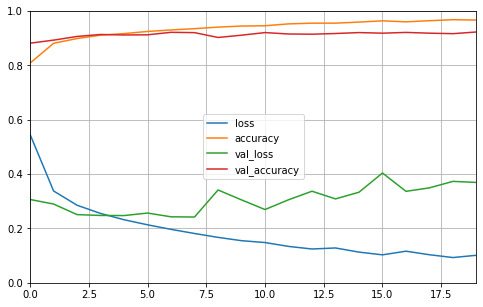

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1);

Evaluate the model.

In [ ]:
## YOUR CODE HERE ##

In [ ]:
model = load_model('conv_fashion_model.h5')
y_hat = model.predict_classes(X_test)

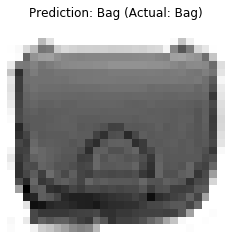

In [ ]:
plot_prediction()

In [ ]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1000
           1       0.99      0.99      0.99      1000
           2       0.81      0.90      0.85      1000
           3       0.91      0.93      0.92      1000
           4       0.86      0.85      0.85      1000
           5       0.99      0.98      0.98      1000
           6       0.80      0.69      0.74      1000
           7       0.96      0.97      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

